# <center>        **Introduction to Data Science (S2-22_DSECLZG532)-ASSIGNMENT**</center>

## Group No - 24

## Group Member Names:
1.Bholay Nath Singh                                                     
2.Dipanjan Chatterjee                                   
3.Mohamed Muzammil Mohamed Anwar                            
4.Rajarajeshwari LV

# 1. Business Understanding

Students are expected to identify an analytical problem of your choice. You have to detail the Business Understanding part of your problem under this heading which basically addresses the following questions.

   1. What is the business problem that you are trying to solve?
   2. What data do you need to answer the above problem?
   3. What are the different sources of data?
   4. What kind of analytics task are you performing?

Score: 1 Mark in total (0.25 mark each)

# 2. Data Acquisition

For the problem identified , find an appropriate data set (Your data set must
be unique with minimum **20 features and 10k rows**) from any public data source.

---



## 2.1 Download the data directly



In [64]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("marusagar/bank-transaction-fraud-detection")
files = os.listdir(path)
print("Extracted files:", files)

Extracted files: ['Bank_Transaction_Fraud_Detection.csv']


## 2.2 Code for converting the above downloaded data into a dataframe

In [65]:
# Identify the first CSV file
csv_file = [file for file in files if file.endswith('.csv')][0]

# Load the CSV file into a DataFrame
df = pd.read_csv(os.path.join(path, csv_file))

# Display first few rows
df.shape


(200000, 24)

## 2.3 Confirm the data has been correctly by displaying the first 5 and last 5 records.

In [66]:
print('first 5 rows -')
print(df.head())
print()
print('last 5 rows -')
print(df.tail())

first 5 rows -
                            Customer_ID        Customer_Name  Gender  Age  \
0  d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e           Osha Tella    Male   60   
1  7c14ad51-781a-4db9-b7bd-67439c175262      Hredhaan Khosla  Female   51   
2  3a73a0e5-d4da-45aa-85f3-528413900a35       Ekani Nazareth    Male   20   
3  7902f4ef-9050-4a79-857d-9c2ea3181940  Yamini Ramachandran  Female   57   
4  3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9         Kritika Rege  Female   43   

         State                City                Bank_Branch Account_Type  \
0       Kerala  Thiruvananthapuram  Thiruvananthapuram Branch      Savings   
1  Maharashtra              Nashik              Nashik Branch     Business   
2        Bihar           Bhagalpur           Bhagalpur Branch      Savings   
3   Tamil Nadu             Chennai             Chennai Branch     Business   
4       Punjab            Amritsar            Amritsar Branch      Savings   

                         Transaction_ID Transaction_D

In [67]:
df.isna().sum()

,0
Customer_ID,0
Customer_Name,0
Gender,0
Age,0
State,0
City,0
Bank_Branch,0
Account_Type,0
Transaction_ID,0
Transaction_Date,0


## 2.4 Display the column headings, statistical information, description and statistical summary of the data.

In [68]:
print("Column Headings:", df.columns.tolist())

print("\nStatistical Summary:")
print(df.describe())

print("\nDataFrame Info:")
df.info()

Column Headings: ['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date', 'Transaction_Time', 'Transaction_Amount', 'Merchant_ID', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud', 'Transaction_Currency', 'Customer_Contact', 'Transaction_Description', 'Customer_Email']

Statistical Summary:
                 Age  Transaction_Amount  Account_Balance       Is_Fraud
count  200000.000000       200000.000000    200000.000000  200000.000000
mean       44.015110        49538.015554     52437.988784       0.050440
std        15.288774        28551.874004     27399.507128       0.218852
min        18.000000           10.290000      5000.820000       0.000000
25%        31.000000        24851.345000     28742.395000       0.000000
50%        44.000000        49502.440000     52372.555000       0.000000
75%        57.000000        74314.6

## 2.5 Write your observations from the above.
1. Size of the dataset
2. What type of data attributes are there?
3. Is there any null data that has to be cleaned?



# 3. Data Preparation

## 3.1 Check for

* duplicate data
* missing data
* data inconsistencies


In [69]:
print("Duplicate Rows:", df.duplicated().sum())

print("\nMissing Values:\n", df.isnull().sum())

print("\nData Types:\n", df.dtypes)
print("\nUnique Values in Each Column:\n", df.nunique())


Duplicate Rows: 0

Missing Values:
 Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64

Data Types:
 Customer_ID                 object
Customer_Name               object
Gender                      object
Age                          int64
State                       object
City                        object
Bank_Branch                 obj

In [70]:
unique_cities = df['City'].unique()
unique_states = df['State'].unique()
unique_transaction_types = df['Transaction_Type'].unique()

print("Unique Cities:", unique_cities)
print()
print("Unique States:", unique_states)
print()
print("Unique Transaction Types:", unique_transaction_types)

Unique Cities: ['Thiruvananthapuram' 'Nashik' 'Bhagalpur' 'Chennai' 'Amritsar'
 'Ahmedabad' 'New Delhi' 'Port Blair' 'Bhopal' 'Jagdalpur' 'Vadodara'
 'Chandigarh' 'Champhai' 'Korba' 'Kolkata' 'Gaya' 'Jorethang' 'Silvassa'
 'Kanpur' 'Nagpur' 'Bhubaneswar' 'Ambassa' 'Jorhat' 'Diglipur' 'Salem'
 'Durg' 'Churachandpur' 'Kottayam' 'Varanasi' 'Imphal' 'Belgaum' 'Agra'
 'Durgapur' 'Daman' 'Bilaspur' 'Nellore' 'Patiala' 'Jabalpur' 'Mapusa'
 'Agartala' 'Aurangabad' 'Gurugram' 'Vijayawada' 'Kavaratti' 'Bokaro'
 'Siliguri' 'Udaipur' 'Nongstoin' 'Tirupati' 'Jamshedpur' 'Ludhiana'
 'Aizawl' 'Raipur' 'Naharlagun' 'Trichur' 'Kohima' 'Ambala' 'Hisar'
 'Nizamabad' 'Dibrugarh' 'Karimnagar' 'Jodhpur' 'Khammam' 'Jaipur' 'Wokha'
 'Mysore' 'Hyderabad' 'Kota' 'Tawang' 'Ziro' 'Shimla' 'Kolasib'
 'West Delhi' 'Vasco da Gama' 'Namchi' 'Thoubal' 'Tura' 'Pune' 'Diu'
 'Hubli' 'Ranchi' 'Yanam' 'South Delhi' 'Mokokchung' 'North Delhi' 'Surat'
 'Dehradun' 'Hazaribagh' 'Mumbai' 'Visakhapatnam' 'Manali' 'Rourkela'
 'Ca

## 3.2 Apply techiniques
* to remove duplicate data
* to impute or remove missing data
* to remove data inconsistencies


#### The dataset doesnt has any duplicate value, or null values that need to be treated, but still we are giving a commented code to treat such cases.

In [71]:
# df = df.drop_duplicates()

# df = df.dropna()

print(df.head())

                            Customer_ID        Customer_Name  Gender  Age  \
0  d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e           Osha Tella    Male   60   
1  7c14ad51-781a-4db9-b7bd-67439c175262      Hredhaan Khosla  Female   51   
2  3a73a0e5-d4da-45aa-85f3-528413900a35       Ekani Nazareth    Male   20   
3  7902f4ef-9050-4a79-857d-9c2ea3181940  Yamini Ramachandran  Female   57   
4  3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9         Kritika Rege  Female   43   

         State                City                Bank_Branch Account_Type  \
0       Kerala  Thiruvananthapuram  Thiruvananthapuram Branch      Savings   
1  Maharashtra              Nashik              Nashik Branch     Business   
2        Bihar           Bhagalpur           Bhagalpur Branch      Savings   
3   Tamil Nadu             Chennai             Chennai Branch     Business   
4       Punjab            Amritsar            Amritsar Branch      Savings   

                         Transaction_ID Transaction_Date  ...  \
0  

## 3.3 Encode categorical data

In [72]:
df.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Amount', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Customer_Contact', 'Transaction_Description',
       'Customer_Email'],
      dtype='object')

In [73]:
df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'], format='%H:%M:%S').dt.time
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='%d-%m-%Y')

def time_bins(time):
    if time >= pd.to_datetime('05:00:00').time() and time < pd.to_datetime('12:00:00').time():
        return 'Morning'
    elif time >= pd.to_datetime('12:00:00').time() and time < pd.to_datetime('17:00:00').time():
        return 'Afternoon'
    elif time >= pd.to_datetime('17:00:00').time() and time < pd.to_datetime('21:00:00').time():
        return 'Evening'
    else:
        return 'Night'



def date_bins(date):
    if date.month in [1, 2, 3]:
        return '1st Quarter'
    elif date.month in [4, 5, 6]:
        return '2nd Quarter'
    elif date.month in [7, 8, 9]:
        return '3rd Quarter'
    else:
        return '4th Quarter'


df['Time_Bin'] = df['Transaction_Time'].apply(time_bins)
df['Date_Bin'] = df['Transaction_Date'].apply(date_bins)

In [74]:
df.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Amount', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Customer_Contact', 'Transaction_Description',
       'Customer_Email', 'Time_Bin', 'Date_Bin'],
      dtype='object')

In [75]:
!pip install category_encoders

In [76]:
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import StandardScaler

# Step 1: Identify columns
target_col = 'Is_Fraud'

categorical_cols = ['Gender', 'State', 'City', 'Bank_Branch', 'Account_Type',
                    'Transaction_Type', 'Merchant_Category', 'Transaction_Device','Transaction_Description',
                    'Transaction_Location', 'Device_Type', 'Transaction_Currency','Time_Bin', 'Date_Bin']

numerical_cols = ['Age', 'Transaction_Amount', 'Account_Balance']

# Step 2: Apply Target Encoding
encoder = TargetEncoder()
df_encoded = df.copy()
df_encoded[categorical_cols] = encoder.fit_transform(df_encoded[categorical_cols], df_encoded[target_col])

# Drop unnecessary columns (IDs, contacts)
drop_cols = ['Customer_ID', 'Customer_Name', 'Transaction_ID', 'Merchant_ID',
             'Transaction_Date', 'Transaction_Time', 'Customer_Contact',
             'Customer_Email']
df_encoded = df_encoded.drop(columns=drop_cols)

# Save encoded data
encoded_df = df_encoded.copy()

print("\nEncoded DataFrame (encoded_df):")
print(encoded_df.head())

print("\nShape of Encoded DataFrame:")
print(encoded_df.shape)


Encoded DataFrame (encoded_df):
     Gender  Age     State      City  Bank_Branch  Account_Type  \
0  0.050581   60  0.045340  0.048246     0.048246      0.050291   
1  0.050297   51  0.050830  0.048000     0.048000      0.051682   
2  0.050581   20  0.046611  0.042142     0.042142      0.050291   
3  0.050297   57  0.056155  0.050818     0.050818      0.051682   
4  0.050297   43  0.047192  0.043515     0.043515      0.050291   

   Transaction_Amount  Transaction_Type  Merchant_Category  Account_Balance  \
0            32415.45          0.051886           0.050350         74557.27   
1            43622.60          0.049276           0.050350         74622.66   
2            63062.56          0.049276           0.051888         66817.99   
3            14000.72          0.050762           0.048233         58177.08   
4            18335.16          0.051886           0.048233         16108.56   

   Transaction_Device  Transaction_Location  Device_Type  Is_Fraud  \
0            0.0512

In [77]:
scaler = StandardScaler()
df_std = df_encoded.copy()
df_std[numerical_cols] = scaler.fit_transform(df_std[numerical_cols])

# Save standardized data
std_df = df_std.copy()

print("\nStandardized DataFrame (std_df):")
print(std_df.head())


Standardized DataFrame (std_df):
     Gender       Age     State      City  Bank_Branch  Account_Type  \
0  0.050581  1.045534  0.045340  0.048246     0.048246      0.050291   
1  0.050297  0.456865  0.050830  0.048000     0.048000      0.051682   
2  0.050581 -1.570771  0.046611  0.042142     0.042142      0.050291   
3  0.050297  0.849311  0.056155  0.050818     0.050818      0.051682   
4  0.050297 -0.066396  0.047192  0.043515     0.043515      0.050291   

   Transaction_Amount  Transaction_Type  Merchant_Category  Account_Balance  \
0           -0.599702          0.051886           0.050350         0.807290   
1           -0.207182          0.049276           0.050350         0.809676   
2            0.473684          0.049276           0.051888         0.524828   
3           -1.244660          0.050762           0.048233         0.209460   
4           -1.092851          0.051886           0.048233        -1.325919   

   Transaction_Device  Transaction_Location  Device_Type  

## 3.4 Report

Mention and justify the method adopted
* to remove duplicate data, if present
* to impute or remove missing data, if present
* to remove data inconsistencies, if present

OR for textdata
* How many tokens after step 3?
* how may tokens after stop words filtering?

If the any of the above are not present, then also add in the report below.

Score: 2 Marks (based on the dataset you have, the data prepreation you had to do and report typed, marks will be distributed between 3.1, 3.2, 3.3 and 3.4)

**REPORT**

**No Missing Data:** The dataset contains no null values, so no imputation or removal of missing data was necessary.


**No Duplicate Data:** There were no duplicate rows, so no duplication removal was performed.


**No Data Inconsistencies:** No inconsistencies in text data or other features were found, so no additional cleaning was required.


**Categorical Encoding:**
Target encoding was applied to the categorical variables to retain useful information while minimizing dimensionality and potential overfitting risks.Target encoding was used over label and one-hot encoding because it captures the relationship between categorical features and the target variable, improving model performance while reducing dimensionality. Unlike label encoding, which imposes an ordinal relationship, and one-hot encoding, which increases dimensionality, target encoding provides more informative and compact representations for high-cardinality features.


**Data Standardization:** StandardScaler() was applied to numerical data to ensure all features are on the same scale, which helps prevent bias during model training and improves the performance of machine learning models.


**Binning Date/Time Variables:** The Transaction_Date and Transaction_Time columns were transformed into bins to simplify the use of these features and capture seasonal or time-of-day patterns, as raw date and time formats cannot be directly used in ML models.

## 3.5 Identify the target variables.

* Separate the data from the target such that the dataset is in the form of (X,y) or (Features, Label)

* Discretize / Encode the target variable or perform one-hot encoding on the target or any other as and if required.

* Report the observations

Score: 1 Mark

In [78]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

X = std_df.drop(columns=['Is_Fraud','Transaction_Currency'])
y = std_df['Is_Fraud']

# Check the unique values in the target variable
print("Target Variable Distribution:\n", y.value_counts())

Target Variable Distribution:
 Is_Fraud
0    189912
1     10088
Name: count, dtype: int64


**Is_Fraud** is the attribute which is the target attribute and holds the information weather the case is Fraudulant or not. 0 means **Not-Fraud** and 1 means **Fraud** and the cases are highly imbalanced.

# 4. Data Exploration using various plots



## 4.1 Scatter plot of each quantitative attribute with the target.

Score: 1 Mark

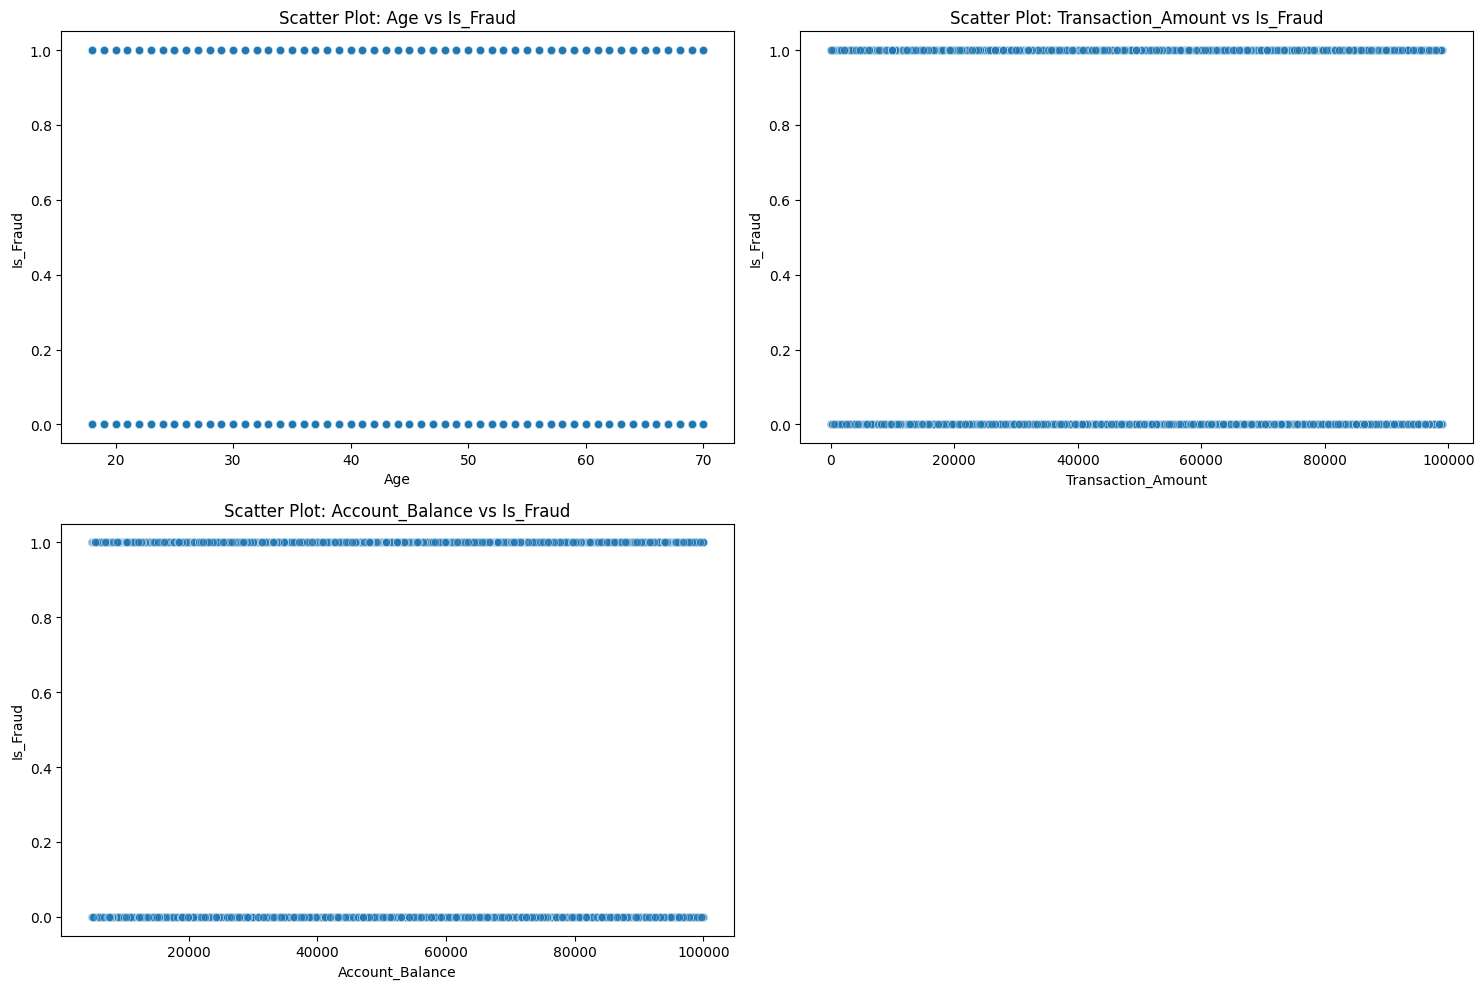

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

quantitative_columns = ['Age', 'Transaction_Amount', 'Account_Balance']

plt.figure(figsize=(15, 10))

for i, col in enumerate(quantitative_columns, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(x=df[col], y=y, alpha=0.6)
    plt.title(f'Scatter Plot: {col} vs Is_Fraud')
    plt.xlabel(col)
    plt.ylabel('Is_Fraud')

plt.tight_layout()
plt.show()

## 4.2 EDA using visuals
* Use (minimum) 2 plots (pair plot, heat map, correlation plot, regression plot...) to identify the optimal set of attributes that can be used for classification.
* Name them, explain why you think they can be helpful in the task and perform the plot as well. Unless proper justification for the choice of plots given, no credit will be awarded.

Score: 2 Marks

In [80]:
std_df.columns

Index(['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type',
       'Transaction_Amount', 'Transaction_Type', 'Merchant_Category',
       'Account_Balance', 'Transaction_Device', 'Transaction_Location',
       'Device_Type', 'Is_Fraud', 'Transaction_Currency',
       'Transaction_Description', 'Time_Bin', 'Date_Bin'],
      dtype='object')

In [81]:
corr_df =std_df [['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type',
       'Transaction_Amount', 'Transaction_Type', 'Merchant_Category',
       'Account_Balance', 'Transaction_Device', 'Transaction_Location',
       'Device_Type', 'Is_Fraud','Transaction_Description', 'Time_Bin', 'Date_Bin']]

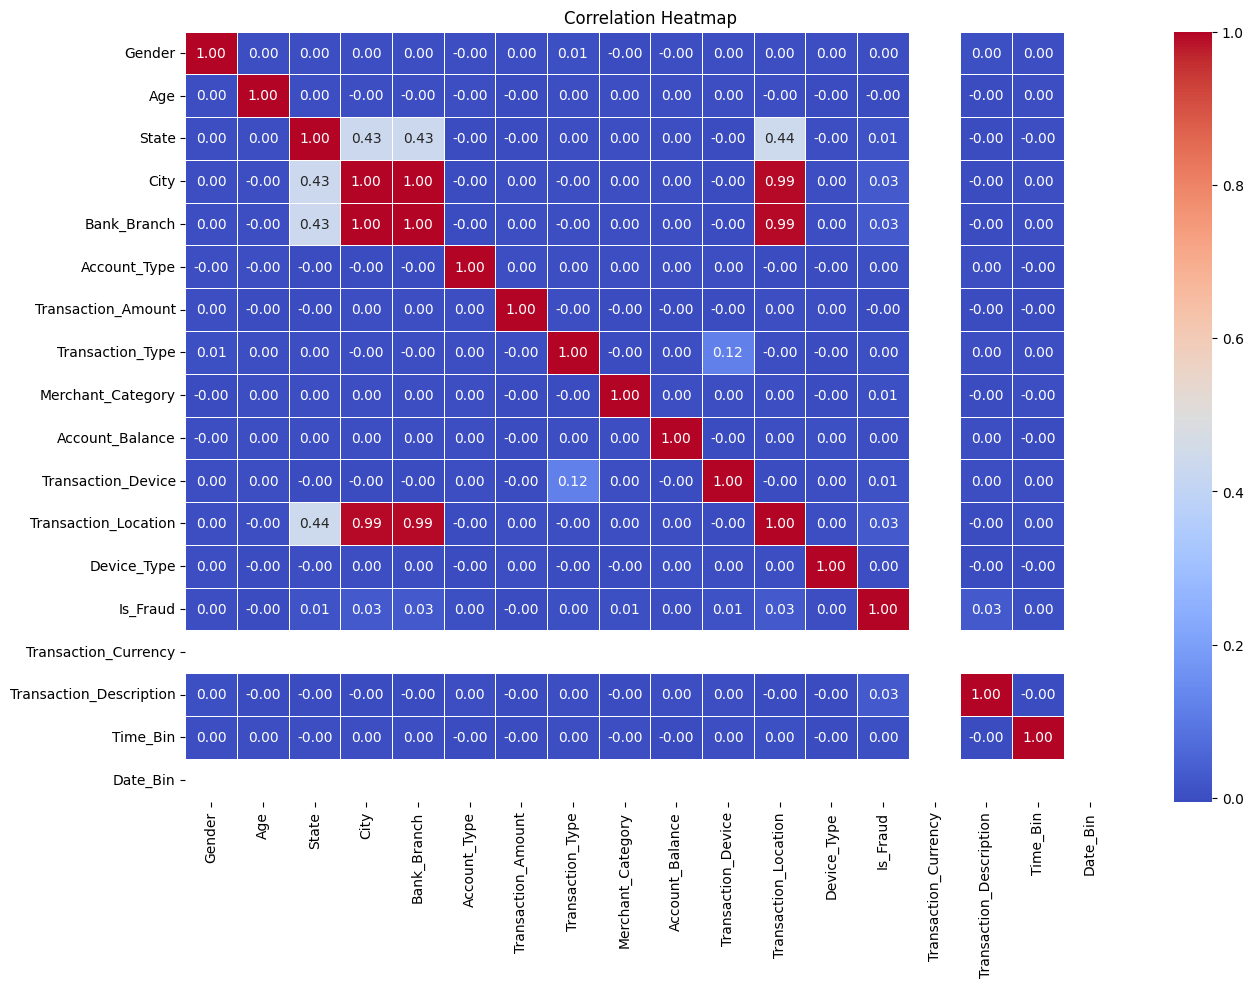

In [82]:
correlation_matrix = std_df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

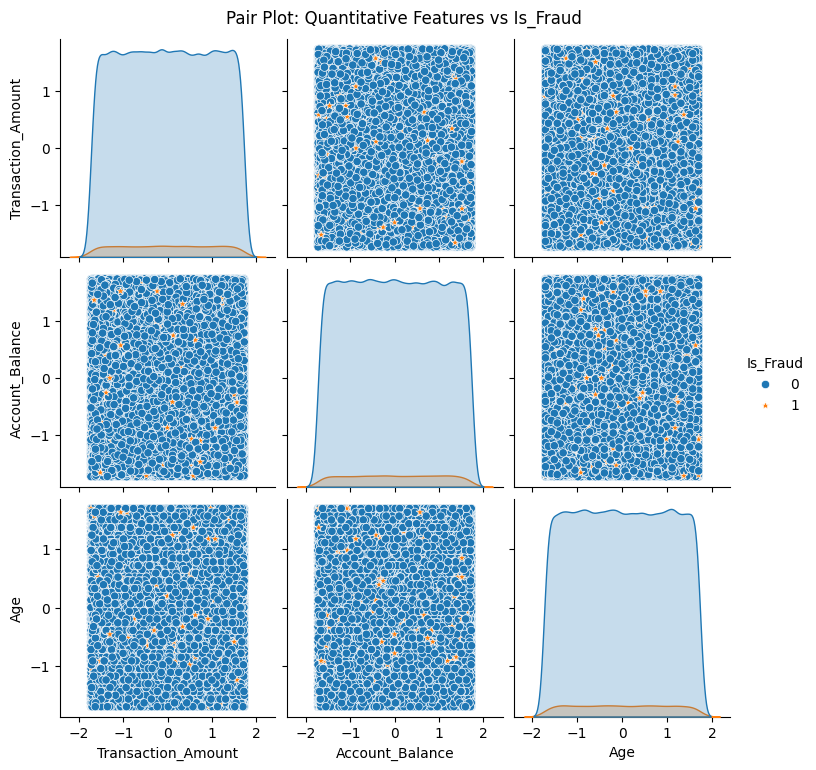

In [83]:
pairplot_columns = ['Transaction_Amount', 'Account_Balance', 'Age', 'Is_Fraud']
sns.pairplot(std_df[pairplot_columns], hue='Is_Fraud', diag_kind='kde', markers=["o", "*"])
plt.suptitle('Pair Plot: Quantitative Features vs Is_Fraud', y=1.02)
plt.show()

**EDA Findings Report**


1- there is no certain pattern in the defaulter on the basis of the Quantitative attributes scatter plot , and the defaulters are evenly spread.

2- the values of the correlation graph shows that attributes like "Transaction_Currency","Date_Bin" has a single value thats why in corr heat map its blank.

3- The pair plot shows if certain ranges of Transaction_Amount or Account_Balance prominently feature star markers, those ranges may represent higher fraud risk.

# 5. Data Wrangling



## 5.1 Univariate Filters

#### Numerical and Categorical Data
* Identify top 5 significant features by evaluating each feature independently with respect to the target/other variable by exploring
1. Mutual Information (Information Gain)
2. Gini index
3. Gain Ratio
4. Chi-Squared test
5. Strenth of Association

(From the above 5 you are required to use only any <b>two</b>)



Score: 3 Marks

In [84]:
from sklearn.feature_selection import mutual_info_classif

# Select features (drop non-informative ones)
x_feature_significance = std_df.drop(columns=['Is_Fraud'])

y_feature_significance = std_df['Is_Fraud']

#### Gini index

In [85]:
from sklearn.tree import DecisionTreeClassifier

# Fit a decision tree model
dt = DecisionTreeClassifier(criterion='gini', random_state=42)
dt.fit(x_feature_significance, y_feature_significance)

# Extract feature importances
gini_importance = pd.DataFrame({'Feature': x_feature_significance.columns, 'Gini Importance': dt.feature_importances_})
gini_importance = gini_importance.sort_values(by='Gini Importance', ascending=False)
print("Top Features by Gini Index:\n", gini_importance.head(5))


Top Features by Gini Index:
                     Feature  Gini Importance
6        Transaction_Amount         0.185774
9           Account_Balance         0.176440
1                       Age         0.101578
14  Transaction_Description         0.100769
10       Transaction_Device         0.064703


#### Chi-squared test

In [86]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

x_norm = df_encoded.drop(columns=['Is_Fraud'])
y_normalised = df_encoded['Is_Fraud']

# Normalize numerical features
scaler = MinMaxScaler()
x_normalised = scaler.fit_transform(x_norm)

# Compute Chi-Square scores
chi_scores, p_values = chi2(x_normalised, y_normalised)

chi_df = pd.DataFrame({'Feature': x_norm.columns, 'Chi2 Score': chi_scores, 'P-value': p_values})
chi_df = chi_df.sort_values(by='Chi2 Score', ascending=False)
print("Top Features by Chi-Squared Test:\n", chi_df.head(5))

Top Features by Chi-Squared Test:
                     Feature  Chi2 Score   P-value
14  Transaction_Description   14.338800  0.000153
11     Transaction_Location   10.182978  0.001417
3                      City    9.942660  0.001615
4               Bank_Branch    9.942660  0.001615
2                     State    4.025287  0.044823


## 5.2 Report observations

Write your observations from the results of each method. Clearly justify your choice of the method.

Score 1 mark

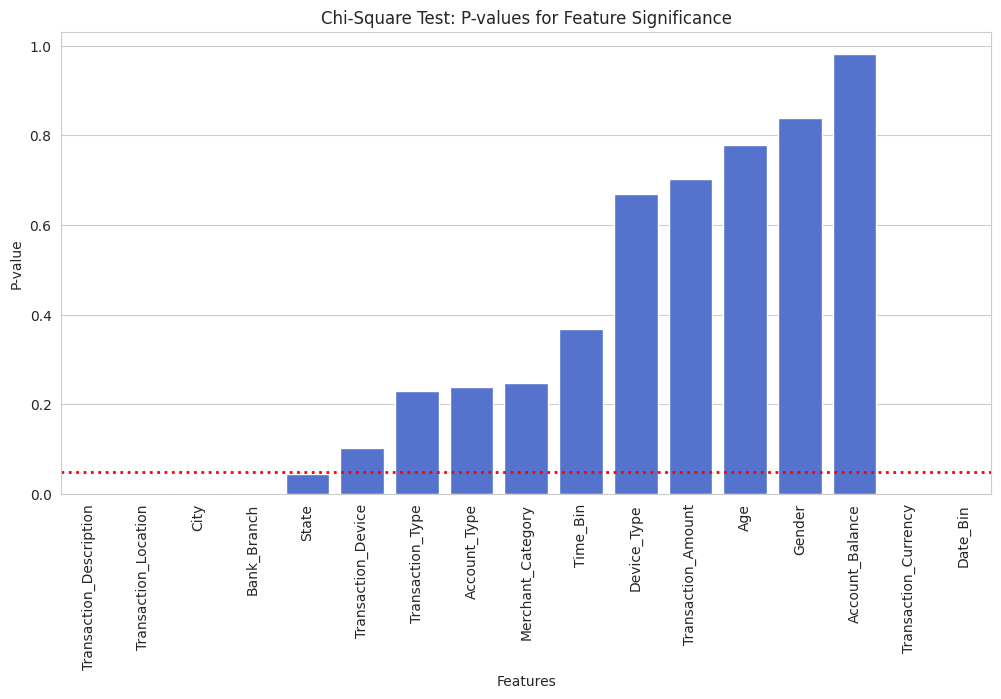

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot size and style
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create the barplot
ax = sns.barplot(x=chi_df['Feature'], y=chi_df['P-value'], color='royalblue')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Add a dotted red line at p = 0.05
plt.axhline(y=0.05, color='red', linestyle='dotted', linewidth=2)

# Add labels and title
plt.xlabel("Features")
plt.ylabel("P-value")
plt.title("Chi-Square Test: P-values for Feature Significance")

# Show the plot
plt.show()

**REPORT**

In this analysis, we first used the **Gini Index** on the standardized data to identify the top 5 features most strongly associated with the target variable, `Is_Fraud`. The Gini Index helped us determine which features contributed most to class separation, highlighting the most important attributes for classification.

Next, we applied the **Chi-Square Test** on the normalized data to assess the relationship between the top 5 features and the target variable. A p-value threshold of 0.05 was set, with features having p-values below this threshold considered statistically significant.

However, we also retained features with higher p-values if they were deemed crucial from a **business perspective**, recognizing that certain features like `Transaction_Type` or `Merchant_Category` may hold practical importance despite not meeting the strict statistical significance criteria. This combined approach ensures that the selected features are both statistically relevant and aligned with the business goals of fraud detection.

# 6. Implement Machine Learning Techniques

Use any 2 ML tasks
1. Classification  

2. Clustering  

3. Association Analysis

4. Anomaly detection

You may use algorithms included in the course, e.g. Decision Tree, K-means etc. or an algorithm you learnt on your own with a brief explanation.
A clear justification have to be given for why a certain algorithm was chosen to address your problem.

Score: 4 Marks (2 marks each for each algorithm)

In [88]:
std_df.nunique()

,0
Gender,2
Age,53
State,34
City,144
Bank_Branch,144
Account_Type,3
Transaction_Amount,197978
Transaction_Type,5
Merchant_Category,6
Account_Balance,197954


In [89]:
std_df.columns

Index(['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type',
       'Transaction_Amount', 'Transaction_Type', 'Merchant_Category',
       'Account_Balance', 'Transaction_Device', 'Transaction_Location',
       'Device_Type', 'Is_Fraud', 'Transaction_Currency',
       'Transaction_Description', 'Time_Bin', 'Date_Bin'],
      dtype='object')

In [90]:
std_df = std_df [['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type',
       'Transaction_Amount', 'Transaction_Type', 'Merchant_Category',
       'Account_Balance', 'Transaction_Device', 'Transaction_Location',
       'Device_Type', 'Is_Fraud', 'Transaction_Description', 'Time_Bin']]

In [91]:
X = std_df.drop(columns=['Is_Fraud'])
y = std_df['Is_Fraud']


In [92]:
print('Independent Variables')
print(X.columns.tolist())

print()
print('Dependent Variable')
print(y.name)

Independent Variables
['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Amount', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Description', 'Time_Bin']

Dependent Variable
Is_Fraud


## 6.1 ML technique 1 + Justification

[LightGBM] [Info] Number of positive: 39881, number of negative: 66468
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015818 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3822
[LightGBM] [Info] Number of data points in the train set: 106349, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.857143 -> initscore=1.791764
[LightGBM] [Info] Start training from score 1.791764
[LightGBM] [Info] Number of positive: 31905, number of negative: 53174
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3791
[LightGBM] [Info] Number of data points in the train set: 85079, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.857145 -> initscore=1.791778
[LightGBM] [Info] Start training from score 1.791778
[LightGBM] [War

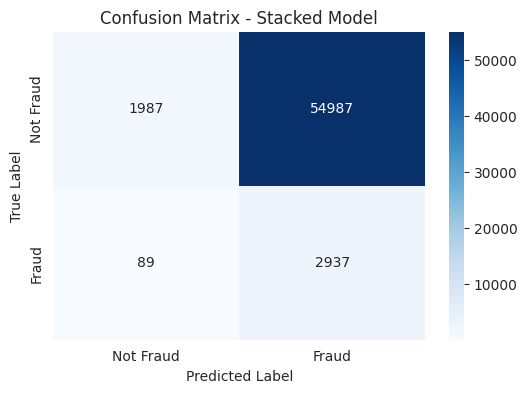

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, roc_curve)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import StackingClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

smote = SMOTE(sampling_strategy=0.3, random_state=42)
undersample = RandomUnderSampler(sampling_strategy=0.6, random_state=42)
pipeline = Pipeline([('smote', smote), ('undersample', undersample)])
X_resampled, y_resampled = pipeline.fit_resample(X_train, y_train)

xgb_model = xgb.XGBClassifier(n_estimators=500, max_depth=7, learning_rate=0.1,
                              scale_pos_weight=15, colsample_bytree=0.8, subsample=0.8,
                              random_state=42, eval_metric='logloss')

lgb_model = lgb.LGBMClassifier(n_estimators=500, max_depth=7, learning_rate=0.1,
                               class_weight={0: 1, 1: 10}, colsample_bytree=0.8, subsample=0.8,
                               random_state=42)

stacked_model = StackingClassifier(estimators=[('xgb', xgb_model), ('lgb', lgb_model)], final_estimator=xgb_model)
stacked_model.fit(X_resampled, y_resampled)

y_prob = stacked_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

best_threshold = thresholds[np.argmax(tpr - fpr)]
adjusted_threshold = min(0.5, best_threshold)

y_pred = (y_prob > adjusted_threshold).astype(int)

# Evaluation of ML Model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_prob)

print("\n Classification Report (Stacked XGBoost + LightGBM):\n", classification_report(y_test, y_pred))
print(f" Best Threshold: {adjusted_threshold:.3f}")
print(f" Accuracy: {accuracy:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")
print(f" F1 Score: {f1:.4f}")
print(f" AUC-ROC Score: {auc_roc:.4f}")

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Stacked Model")
plt.show()


## 6.2 ML technique 2 + Justification


 Silhouette Score for K-Means Clustering: 0.2430


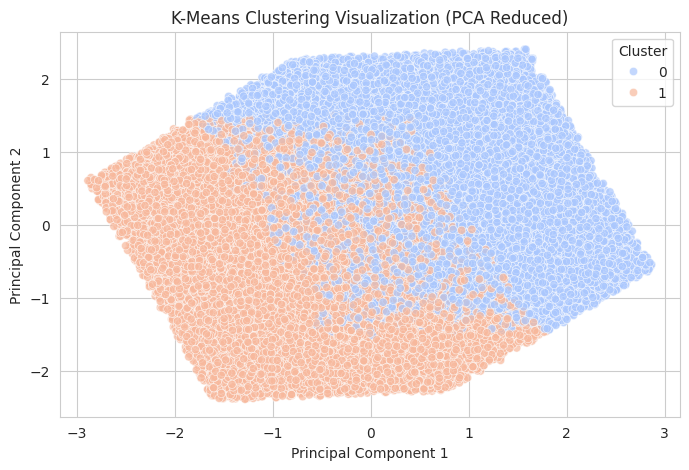

<ipython-input-94-a78e2061969e>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=X["Cluster"], palette="coolwarm")


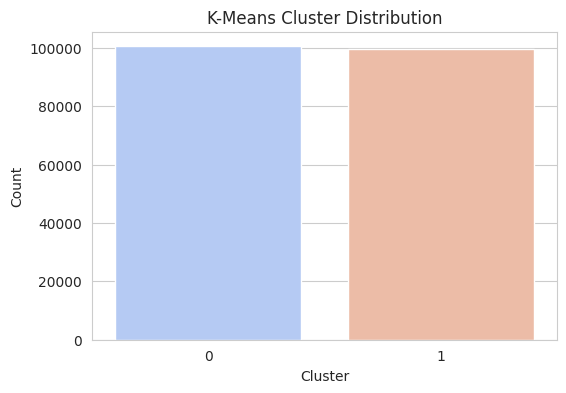

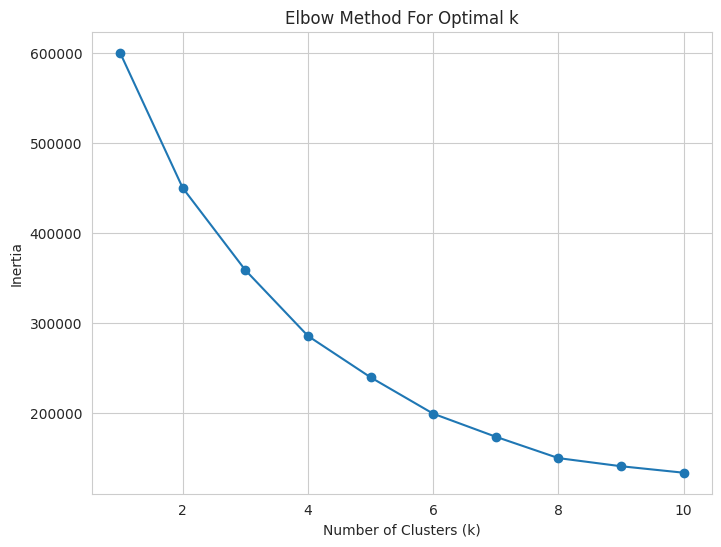

In [94]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
X["Cluster"] = kmeans.fit_predict(X)

# Compute clustering evaluation metrics
silhouette = silhouette_score(X.drop(columns=["Cluster"]), X["Cluster"])

print(f"\n Silhouette Score for K-Means Clustering: {silhouette:.4f}")

# Visualizing Clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.drop(columns=["Cluster"]))

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=X["Cluster"], palette="coolwarm", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Visualization (PCA Reduced)")
plt.legend(title="Cluster")
plt.show()

# Count Plot of Clusters
plt.figure(figsize=(6, 4))
sns.countplot(x=X["Cluster"], palette="coolwarm")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.title("K-Means Cluster Distribution")
plt.show()

# Elbow Method to Determine Optimal Number of Clusters
inertia = []

# Try different values of k (number of clusters)
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X.drop(columns=["Cluster"]))
    inertia.append(kmeans.inertia_)

# Plotting the Elbow graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

## 7. Conclusion

Compare the performance of the ML techniques used.

Derive values for preformance study metrics like accuracy, precision, recall, F1 Score, AUC-ROC etc to compare the ML algos and plot them. A proper comparision based on different metrics should be done and not just accuracy alone, only then the comparision becomes authentic. You may use Confusion matrix, classification report, Word cloud etc as per the requirement of your application/problem.

Score 1 Mark

**Classification Report**

In this process, we experimented with various machine learning models, including Logistic Regression, Decision Trees, and Random Forests, but faced issues with overfitting, which made them unsuitable for our task. To address the class imbalance, we implemented **SMOTE** (Synthetic Minority Oversampling Technique) combined with **RandomUnderSampler** to resample the training data and balance the classes. After trying several models, we settled on a **Stacked Model** using **XGBoost** and **LightGBM** due to their robustness in handling imbalanced datasets. The model was trained using the resampled data, and we adjusted the decision threshold based on the **ROC curve** to optimize the balance between precision and recall. The final evaluation showed a recall of 97.06% for fraud detection, but with a low precision, indicating that while the model is effective at identifying fraud cases, it also has a high number of false positives. The overall performance can be improved further with additional tuning or by using other ensemble techniques.





















**Clustering Report**

In this process, we applied **K-Means Clustering** to segment the dataset into two clusters, and evaluated the clustering performance using the **Silhouette Score**, which yielded a value of **0.2430**, indicating that the clusters are somewhat distinct, though not highly separated. To further analyze the clustering results, we visualized the clusters by reducing the dimensions to two principal components using **PCA (Principal Component Analysis)**, providing a clearer view of how the clusters are distributed. The cluster distribution was also depicted with a **count plot** to showcase the frequency of instances in each cluster. Additionally, we employed the **Elbow Method** to determine the optimal number of clusters. Based on the **inertia values** for different cluster counts, the graph suggested that **k=2** is the optimal choice, as indicated by the "elbow point." This implies that two clusters offer the best balance between clustering accuracy and model complexity.

## 8. Solution

What is the solution that is proposed to solve the business problem discussed in Section 1. Also share your learnings while working through solving the problem in terms of challenges, observations, decisions made etc.

Score 2 Marks

The business problem of detecting fraudulent transactions was addressed by building a **Stacked Model** using **XGBoost** and **LightGBM**, which are well-suited for handling imbalanced data. **SMOTE** and **RandomUnderSampler** were used to balance the dataset and improve model performance. The solution aimed to accurately identify potential fraudsters, ensuring high recall to minimize missed fraudulent cases. The model's performance showed **97% recall**, prioritizing fraud detection over precision to prevent financial losses due to undetected fraud. Key learnings included the importance of handling class imbalance, preventing overfitting, and focusing on recall for fraud detection.